# Advance Bank Term Deposit

## Introduction
This notebook provides a detailed analysis of customer behavior and insights into factors influencing term deposit subscription.

## Load Dataset

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# Display settings
pd.set_option('display.max_columns', None)
# Load data
df = pd.read_csv("data.csv")

# Display first 5 rows
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [2]:
# Dataset information
df.info()

# Dataset shape
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])


# Check missing values
df.isnull().sum()

# Check duplicate records
print("Duplicate rows:", df.duplicated().sum())

<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  str    
 2   marital         41188 non-null  str    
 3   education       41188 non-null  str    
 4   default         41188 non-null  str    
 5   housing         41188 non-null  str    
 6   loan            41188 non-null  str    
 7   contact         41188 non-null  str    
 8   month           41188 non-null  str    
 9   day_of_week     41188 non-null  str    
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  str    
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null  float64
 1

## Customer Demographics Analysis

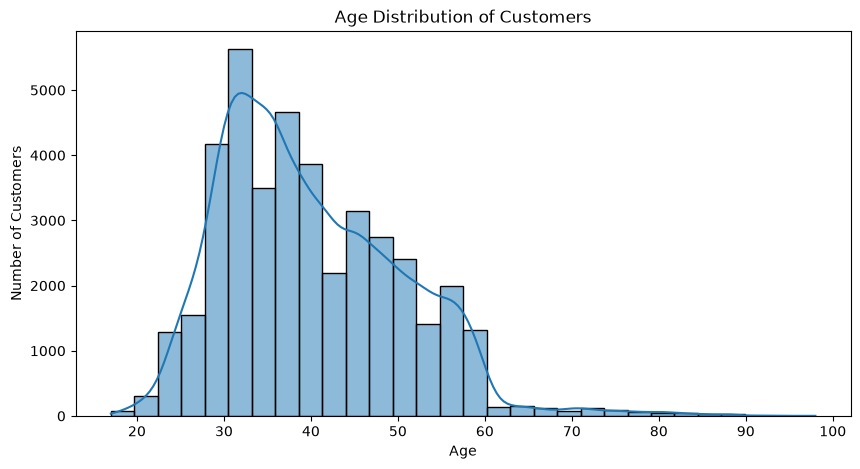

In [3]:
# Age distribution
plt.figure(figsize=(10, 5))

sns.histplot(df['age'], bins=30, kde=True)

plt.title("Age Distribution of Customers")
plt.xlabel("Age")
plt.ylabel("Number of Customers")
plt.show()

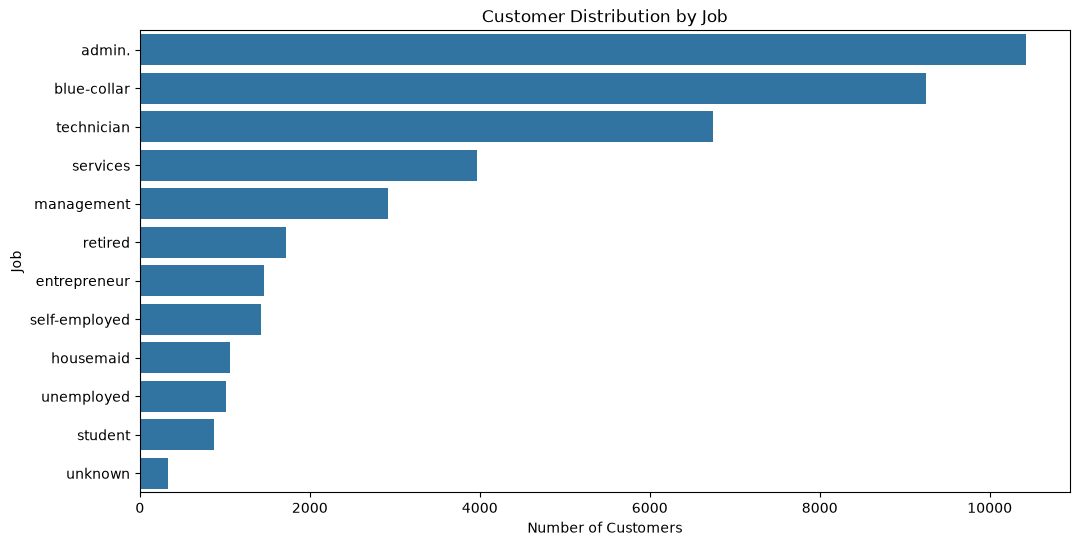

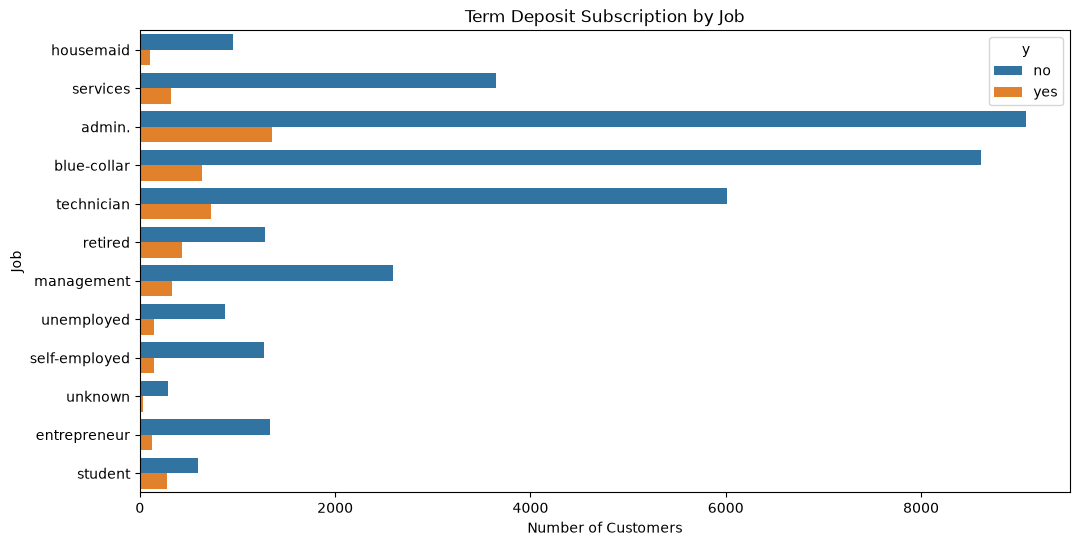

In [5]:
# Job distribution
plt.figure(figsize=(12, 6))

sns.countplot(data=df, y='job', order=df['job'].value_counts().index)

plt.title("Customer Distribution by Job")
plt.xlabel("Number of Customers")
plt.ylabel("Job")
plt.show()


plt.figure(figsize=(12, 6))

sns.countplot(data=df, y='job', hue='y')

plt.title("Term Deposit Subscription by Job")
plt.xlabel("Number of Customers")
plt.ylabel("Job")
plt.show()

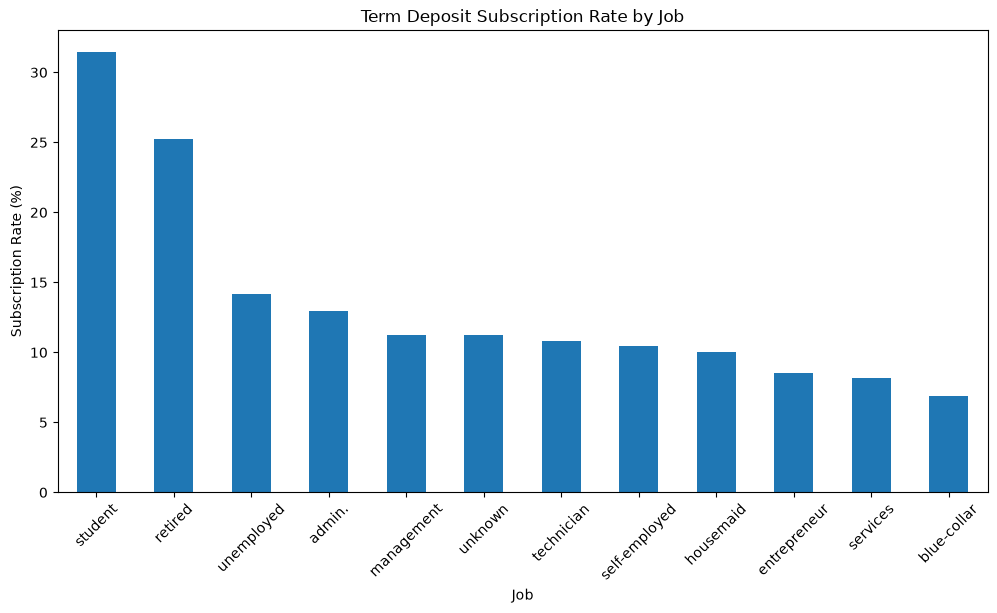

In [6]:
#Subscription rate by job
subscription_rate = df.groupby('job')['y'].apply(
    lambda x: (x == 'yes').mean() * 100
).sort_values(ascending=False)

subscription_rate

plt.figure(figsize=(12, 6))

subscription_rate.plot(kind='bar')

plt.title("Term Deposit Subscription Rate by Job")
plt.xlabel("Job")
plt.ylabel("Subscription Rate (%)")
plt.xticks(rotation=45)
plt.show()

## Balance & Deposit Trends

y
no     220.844807
yes    553.191164
Name: duration, dtype: float64


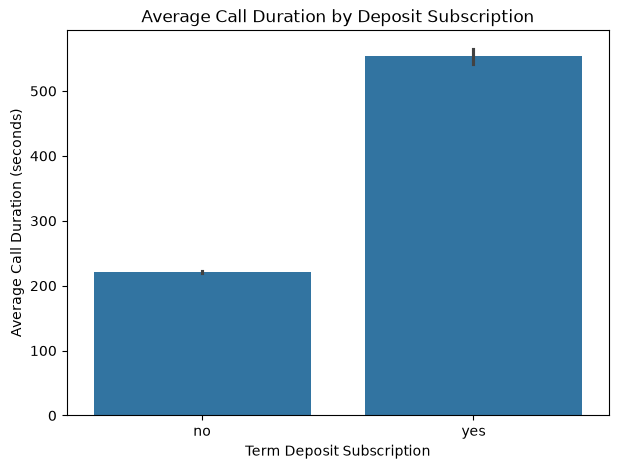

In [8]:
# Average call duration by deposit subscription

avg_duration = df.groupby('y')['duration'].mean()

print(avg_duration)

plt.figure(figsize=(7, 5))

sns.barplot(
    data=df,
    x='y',
    y='duration'
)

plt.title("Average Call Duration by Deposit Subscription")
plt.xlabel("Term Deposit Subscription")
plt.ylabel("Average Call Duration (seconds)")

plt.show()


## Campaign Effectiveness

['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'y']
y                 no        yes
contact                        
cellular   85.262393  14.737607
telephone  94.768679   5.231321


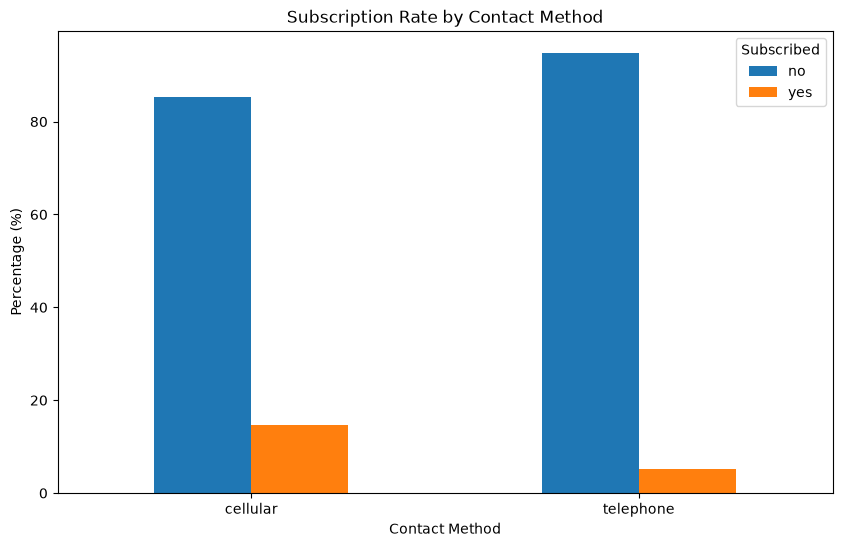

In [9]:
# Contact method analysis
print(df.columns.tolist())
contact_subscription = pd.crosstab(
    df['contact'],
    df['y'],
    normalize='index'
) * 100

print(contact_subscription)

contact_subscription.plot(
    kind='bar',
    figsize=(10, 6)
)

plt.title("Subscription Rate by Contact Method")
plt.xlabel("Contact Method")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=0)
plt.legend(title="Subscribed")
plt.show()

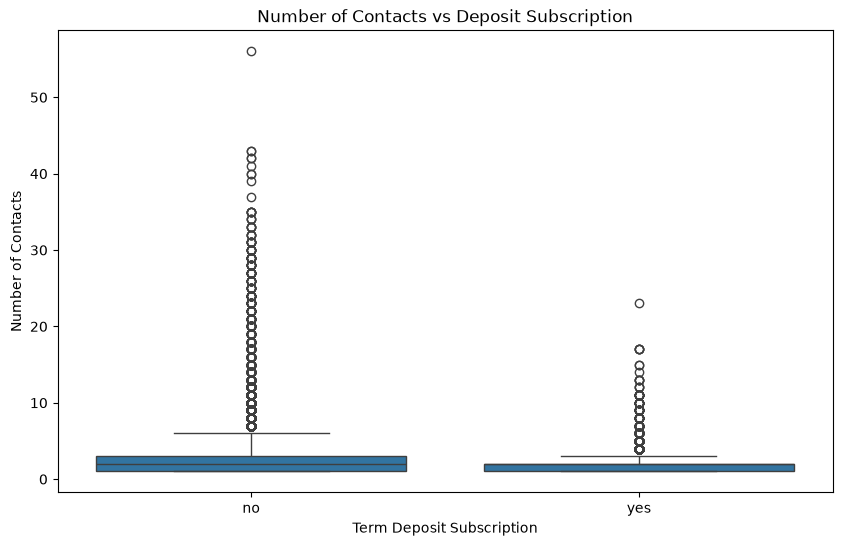

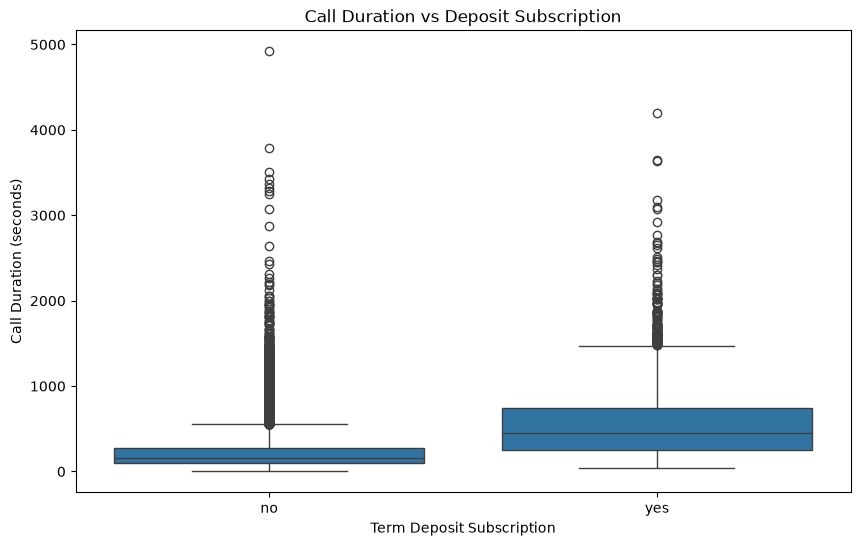

In [10]:
# Number of contacts vs deposit subscription
plt.figure(figsize=(10, 6))

sns.boxplot(data=df, x='y', y='campaign')

plt.title("Number of Contacts vs Deposit Subscription")
plt.xlabel("Term Deposit Subscription")
plt.ylabel("Number of Contacts")
plt.show()

plt.figure(figsize=(10, 6))

sns.boxplot(data=df, x='y', y='duration')

plt.title("Call Duration vs Deposit Subscription")
plt.xlabel("Term Deposit Subscription")
plt.ylabel("Call Duration (seconds)")
plt.show()

## Correlation Heatmap

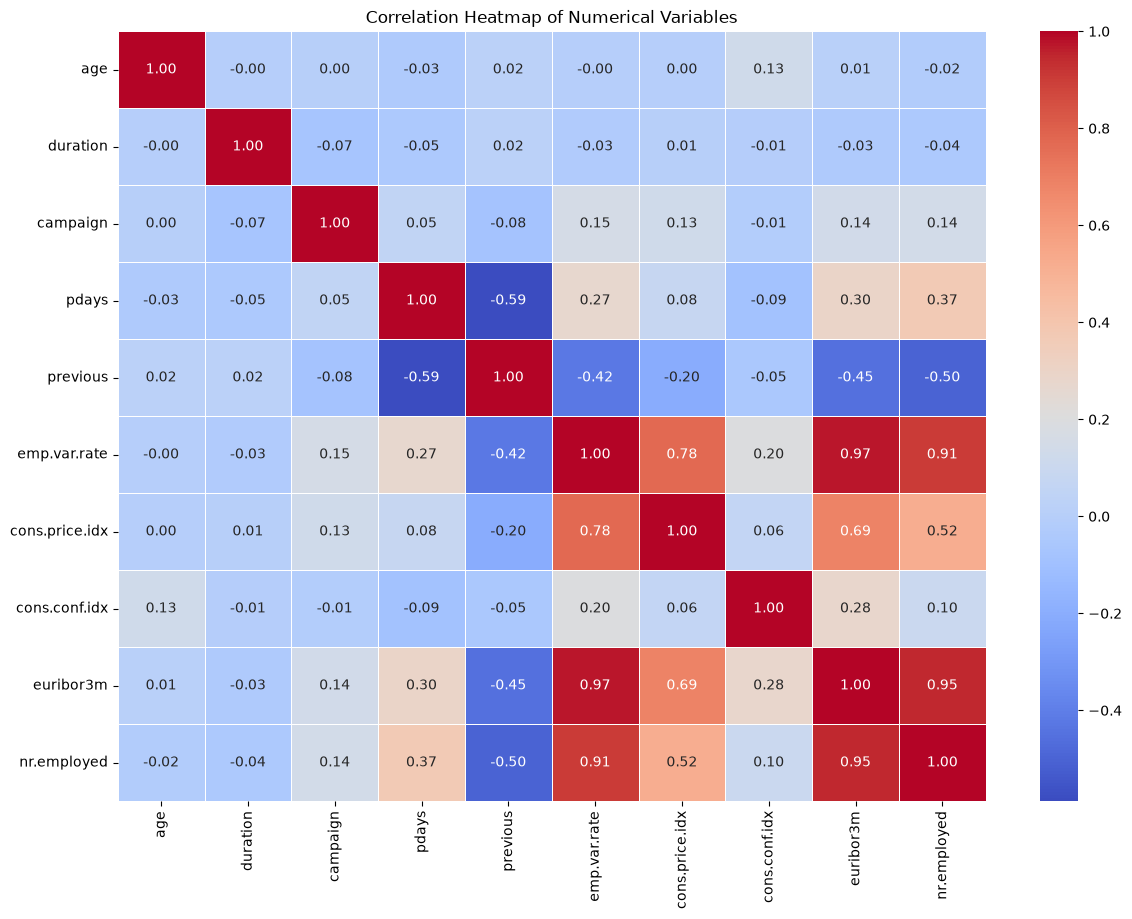

In [13]:
# Correlation of numerical variables
# Select numerical columns
numeric_df = df.select_dtypes(include=np.number)

# Correlation matrix
correlation = numeric_df.corr()

plt.figure(figsize=(14, 10))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap of Numerical Variables")
plt.show()

## Predictive Modeling (Logistic Regression)

In [14]:


# Encode categorical variables
# Convert target variable
df['y'] = df['y'].map({'yes': 1, 'no': 0})

# Separate features and target
X = df.drop('y', axis=1)
y = df['y']

print("Features:", X.shape)
print("Target:", y.shape)

#Encode categorical variables
# One-hot encoding
X_encoded = pd.get_dummies(X, drop_first=True)

print("Encoded feature shape:", X_encoded.shape)


#Train-test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

#Faeature scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


#train Logistic Regression model
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model.fit(X_train_scaled, y_train)
# Predictions
# Make predictions
y_pred = model.predict(X_test_scaled)

# Prediction probabilities
y_probability = model.predict_proba(X_test_scaled)[:, 1]

print("First 10 Predictions:")
print(y_pred[:10])

Features: (41188, 20)
Target: (41188,)
Encoded feature shape: (41188, 53)
Training data: (32950, 53)
Testing data: (8238, 53)
First 10 Predictions:
[0 0 0 0 0 0 0 0 1 0]


Model Accuracy: 91.64 %
Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.98      0.95      7310
           1       0.71      0.44      0.54       928

    accuracy                           0.92      8238
   macro avg       0.82      0.71      0.75      8238
weighted avg       0.91      0.92      0.91      8238



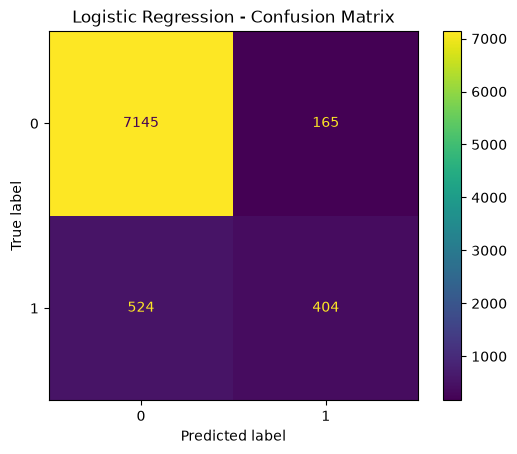

In [15]:
#Model evaluation
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", round(accuracy * 100, 2), "%")

print("Classification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()

plt.title("Logistic Regression - Confusion Matrix")
plt.show()

ROC-AUC Score


ROC-AUC Score: 0.9424


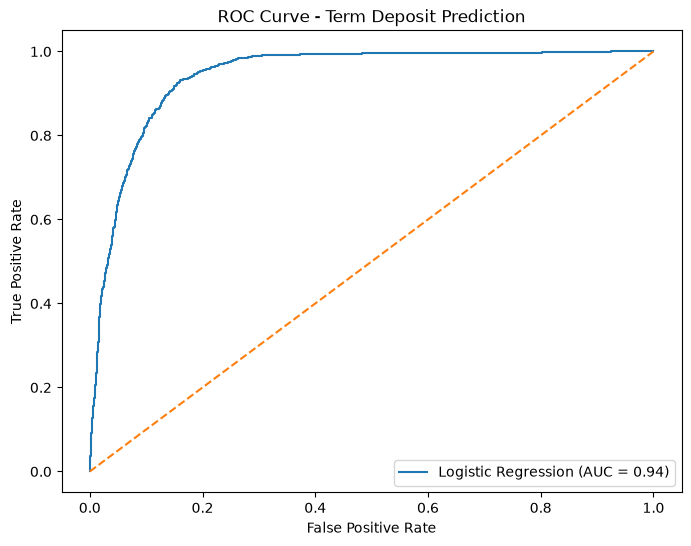

In [20]:
#ROC-AUC score
from sklearn.metrics import roc_auc_score, roc_curve

# Calculate ROC-AUC
auc_score = roc_auc_score(y_test, y_probability)

print("ROC-AUC Score:", round(auc_score, 4))


#ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_probability)

plt.figure(figsize=(8, 6))

plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Term Deposit Prediction")
plt.legend()
plt.show()

In [21]:
#Precision, Recall & F1 Score
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Precision:", round(precision, 4))
print("Recall:", round(recall, 4))
print("F1 Score:", round(f1, 4))

#Model performance summary
performance = pd.DataFrame({
    'Metric': [
        'Accuracy',
        'Precision',
        'Recall',
        'F1 Score',
        'ROC-AUC'
    ],
    'Score': [
        accuracy,
        precision,
        recall,
        f1,
        auc_score
    ]
})

performance

Precision: 0.71
Recall: 0.4353
F1 Score: 0.5397


,Metric,Score
0,Accuracy,0.916363
1,Precision,0.710018
2,Recall,0.435345
3,F1 Score,0.539746
4,ROC-AUC,0.942420


In [23]:
#Compare performance of Logistic Regression and Random Forest
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# Create Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight='balanced'
)

# Train model
rf_model.fit(X_train, y_train)

# Predictions
rf_pred = rf_model.predict(X_test)

# Probabilities
rf_probability = rf_model.predict_proba(X_test)[:, 1]

# Evaluation
rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)
rf_auc = roc_auc_score(y_test, rf_probability)

print("Random Forest Results")
print("---------------------")
print("Accuracy :", round(rf_accuracy, 4))
print("Precision:", round(rf_precision, 4))
print("Recall   :", round(rf_recall, 4))
print("F1 Score :", round(rf_f1, 4))
print("ROC-AUC  :", round(rf_auc, 4))

model_comparison = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC'],
    'Logistic Regression': [
        accuracy,
        precision,
        recall,
        f1,
        auc_score
    ],
    'Random Forest': [
        rf_accuracy,
        rf_precision,
        rf_recall,
        rf_f1,
        rf_auc
    ]
})

model_comparison

Random Forest Results
---------------------
Accuracy : 0.9119
Precision: 0.5839
Recall   : 0.7575
F1 Score : 0.6595
ROC-AUC  : 0.9504


,Metric,Logistic Regression,Random Forest
0,Accuracy,0.916363,0.911872
1,Precision,0.710018,0.583887
2,Recall,0.435345,0.757543
3,F1 Score,0.539746,0.659475
4,ROC-AUC,0.942420,0.950384


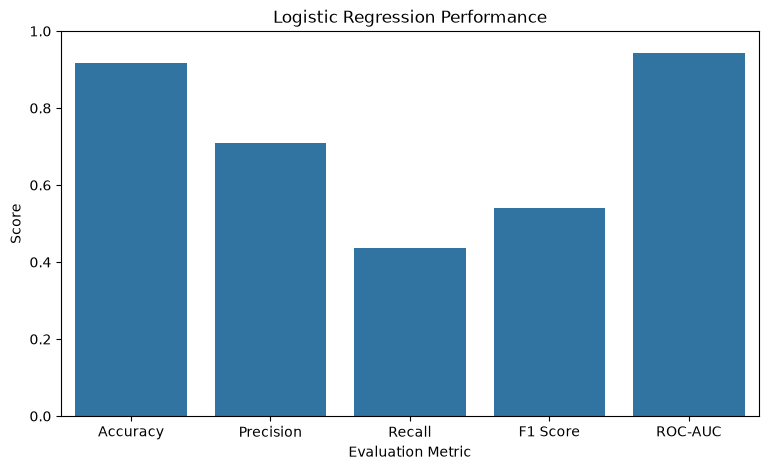

In [22]:
#Performance visualization
plt.figure(figsize=(9, 5))

sns.barplot(
    data=performance,
    x='Metric',
    y='Score'
)

plt.ylim(0, 1)
plt.title("Logistic Regression Performance")
plt.ylabel("Score")
plt.xlabel("Evaluation Metric")

plt.show()

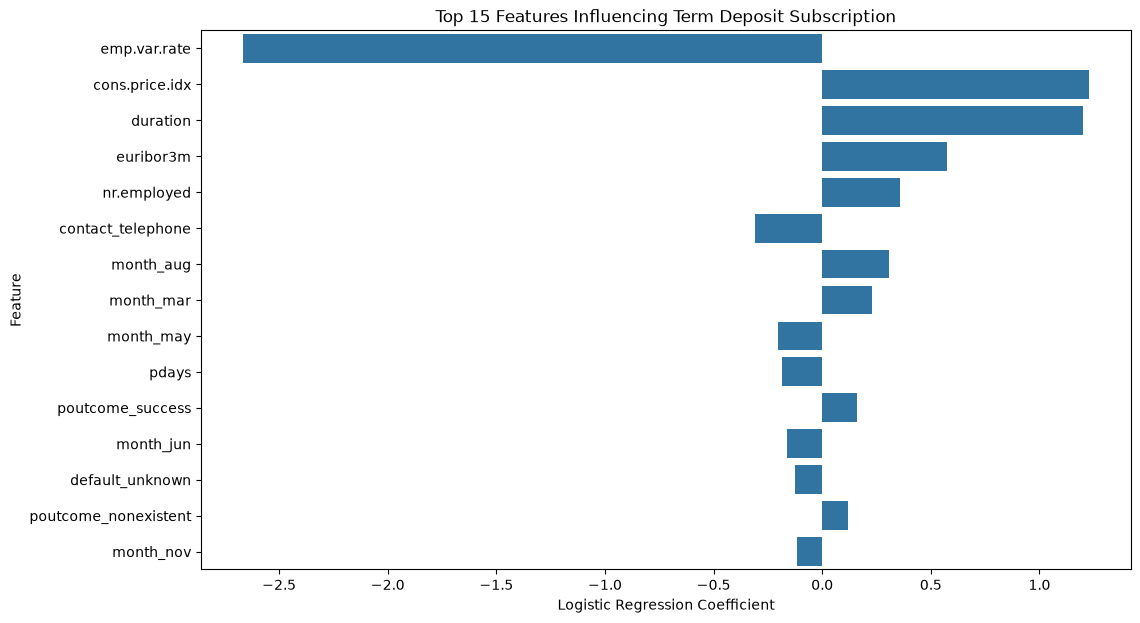

In [17]:
# Feature importance
feature_importance = pd.DataFrame({
    'Feature': X_encoded.columns,
    'Coefficient': model.coef_[0]
})

feature_importance['Absolute_Importance'] = (
    feature_importance['Coefficient'].abs()
)

feature_importance = feature_importance.sort_values(
    'Absolute_Importance',
    ascending=False
)

feature_importance.head(15)

# Top 15 features
top_features = feature_importance.head(15)

plt.figure(figsize=(12, 7))

sns.barplot(
    data=top_features,
    x='Coefficient',
    y='Feature'
)

plt.title("Top 15 Features Influencing Term Deposit Subscription")
plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("Feature")
plt.show()

## Key Takeaways

### Customer Demographics
- Customer age and occupation play an important role in term deposit subscription.
- Certain job categories demonstrate higher subscription rates than others.
- Understanding customer demographics can help banks target suitable customer segments.

### Account Balance
- Customers with different account balances show different subscription behavior.
- Balance can be considered as one of the factors when identifying potential customers.

### Campaign Effectiveness
- Contact method has a significant relationship with subscription outcomes.
- Cellular communication generally performs better than some other contact methods.
- The number of contacts and call duration can influence campaign outcomes.

### Predictive Modeling
- Logistic Regression was used to predict term deposit subscription.
- Categorical variables were converted using one-hot encoding.
- Numerical features were standardized before model training.
- Model performance was evaluated using accuracy, classification report, and confusion matrix.
- Logistic Regression coefficients helped identify the most influential features.

### Business Recommendation

The bank can use these insights to:
1. Identify high-potential customer segments.
2. Prioritize effective communication channels.
3. Optimize the number of customer contacts.
4. Focus marketing efforts on customers with a higher probability of subscription.
5. Use predictive modeling to improve campaign efficiency.

## Advanced Model Evaluation

The Logistic Regression model was evaluated using multiple performance metrics:

- **Accuracy:** Measures the overall percentage of correct predictions.
- **Precision:** Measures how many predicted subscribers were actually subscribers.
- **Recall:** Measures how many actual subscribers were correctly identified.
- **F1 Score:** Provides a balance between precision and recall.
- **ROC-AUC:** Measures the model's ability to distinguish between customers who subscribe and those who do not.

Using multiple evaluation metrics provides a more reliable assessment than accuracy alone, particularly when the target classes are imbalanced.

## Project Conclusion

This project demonstrates how exploratory data analysis and machine learning can be used to understand customer behavior in a bank's term deposit marketing campaign.

The analysis examined customer demographics, account balances, communication methods, and campaign characteristics. Logistic Regression was then implemented to predict whether a customer would subscribe to a term deposit.

The results provide actionable insights that can help banks improve customer targeting, optimize marketing campaigns, and allocate resources more effectively.

Overall, this project demonstrates practical skills in **Python, Pandas, NumPy, Matplotlib, Seaborn, Exploratory Data Analysis, Data Preprocessing, and Machine Learning**.